# Model Comparison - Train ST-GCN (Lightweight)
Notebook นี้ฝึกโมเดล **ST-GCN-inspired** (Graph + Temporal) จาก pose sequence เพื่อใช้เทียบกับ SVM / LSTM-GRU / MLP ใน Results.

In [1]:
import os
import sys
import json
import time
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sys.path.insert(0, os.path.abspath('..'))
import src.config as config
from src.data.processing import create_sequences, video_based_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [2]:
WINDOW_SIZE = 10
STEP_SIZE = 1
BATCH_SIZE = 64
EPOCHS = 25
LEARNING_RATE = 1e-3
PATIENCE = 6

# 14 จุดสำคัญสำหรับโครงสร้างกราฟ (MediaPipe landmark ids)
LANDMARK_IDS = [0, 11, 12, 13, 14, 15, 16, 23, 24, 7, 8, 9, 10, 5]
NUM_NODES = len(LANDMARK_IDS)

def extract_pose_tensor(df_raw, landmark_ids):
    cols = []
    for idx in landmark_ids:
        cols.extend([f'landmark_{idx}_x', f'landmark_{idx}_y', f'landmark_{idx}_z'])
    arr = df_raw[cols].values.astype(np.float32)
    return arr.reshape(len(df_raw), len(landmark_ids), 3)

def create_windows(pose_tensor, window_size=10, step_size=1):
    windows = []
    for i in range(0, len(pose_tensor) - window_size + 1, step_size):
        windows.append(pose_tensor[i:i + window_size])
    return windows

data_dir = os.path.join(config.DATASET_DIR, 'by_class')
X_list, y_list = [], []

for file_name in sorted(os.listdir(data_dir)):
    if not file_name.endswith('.csv'):
        continue
    label = file_name.replace('.csv', '')
    csv_path = os.path.join(data_dir, file_name)
    df_raw = pd.read_csv(csv_path).dropna()
    pose_tensor = extract_pose_tensor(df_raw, LANDMARK_IDS)
    windows = create_windows(pose_tensor, WINDOW_SIZE, STEP_SIZE)

    X_list.extend(windows)
    y_list.extend([label] * len(windows))
    print(f'Loaded {file_name}: {len(windows)} windows')

if not X_list:
    raise RuntimeError('No sequence windows created.')

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list)
print('X shape:', X.shape)  # (N, T, V, C)
print('y shape:', y.shape)

Loaded block.csv: 491 windows
Loaded dodge_back.csv: 291 windows
Loaded dodge_front.csv: 291 windows
Loaded dodge_left.csv: 291 windows


Loaded dodge_right.csv: 291 windows
Loaded final_skill.csv: 291 windows
Loaded left_punch.csv: 291 windows
Loaded neutral.csv: 491 windows
Loaded right_punch.csv: 291 windows
X shape: (3019, 10, 14, 3)
y shape: (3019,)


In [3]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Use VIDEO-BASED SPLIT to prevent data leakage
# chunk_size=50 assumes ~50 consecutive sequences per video chunk
print('\n⚠️  Using VIDEO-BASED SPLIT (no data leakage)')
X_train, X_val, X_test, y_train, y_val, y_test = video_based_split(
    X, y_encoded, test_size=0.2, val_size=0.15, chunk_size=50, random_state=SEED
)

# scale per coordinate channel (x,y,z)
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, X_train.shape[-1]))

def scale_tensor(x):
    shape = x.shape
    x_scaled = scaler.transform(x.reshape(-1, shape[-1])).reshape(shape)
    return x_scaled.astype(np.float32)

X_train = scale_tensor(X_train)
X_val = scale_tensor(X_val)
X_test = scale_tensor(X_test)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long)), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val, dtype=torch.long)), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long)), batch_size=BATCH_SIZE, shuffle=False)

print('Train:', len(X_train), 'Val:', len(X_val), 'Test:', len(X_test))
print('✓ Honest train/val/test split completed')


⚠️  Using VIDEO-BASED SPLIT (no data leakage)
Train: 2000 Val: 419 Test: 600
✓ Honest train/val/test split completed


In [4]:
def build_adjacency(num_nodes):
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    edges = [
        (0, 9), (0, 10), (0, 11), (0, 12), (0, 13),
        (1, 2),
        (1, 3), (3, 5),
        (2, 4), (4, 6),
        (1, 7), (2, 8),
        (7, 8),
        (1, 9), (2, 10)
    ]
    for i, j in edges:
        A[i, j] = 1.0
        A[j, i] = 1.0
    A += np.eye(num_nodes, dtype=np.float32)

    D = np.sum(A, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-8))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    return torch.tensor(A_norm, dtype=torch.float32)

class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_nodes, adjacency):
        super().__init__()
        self.register_buffer('A', adjacency)
        self.spatial_fc = nn.Linear(in_channels, out_channels)
        self.temporal_conv = nn.Conv1d(
            in_channels=out_channels * num_nodes,
            out_channels=out_channels * num_nodes,
            kernel_size=3,
            padding=1,
            groups=num_nodes
        )
        self.bn = nn.BatchNorm1d(out_channels * num_nodes)

    def forward(self, x):
        # x: (B, T, V, C)
        x = torch.einsum('vw,btwc->btvc', self.A, x)
        x = self.spatial_fc(x)
        x = torch.relu(x)

        b, t, v, c = x.shape
        x = x.reshape(b, t, v * c).transpose(1, 2)
        x = self.temporal_conv(x)
        x = self.bn(x)
        x = torch.relu(x)
        x = x.transpose(1, 2).reshape(b, t, v, c)
        return x

class STGCNClassifier(nn.Module):
    def __init__(self, num_nodes, num_classes, in_channels=3):
        super().__init__()
        A = build_adjacency(num_nodes)
        self.block1 = STGCNBlock(in_channels, 32, num_nodes, A)
        self.block2 = STGCNBlock(32, 64, num_nodes, A)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = x.mean(dim=2)
        x = x.transpose(1, 2)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

model = STGCNClassifier(num_nodes=NUM_NODES, num_classes=len(encoder.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_state = None
best_val_loss = float('inf')
wait = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    val_true = []
    val_pred = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)
            val_true.extend(yb.cpu().numpy())
            val_pred.extend(pred.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc = accuracy_score(val_true, val_pred)
    print(f'Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}')

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print('Early stopping triggered')
            break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01/25 | train_loss=1.3202 | val_loss=1.7345 | val_acc=0.6706


Epoch 02/25 | train_loss=0.5934 | val_loss=0.5494 | val_acc=0.8831


Epoch 03/25 | train_loss=0.3151 | val_loss=0.2729 | val_acc=0.9284


Epoch 04/25 | train_loss=0.1875 | val_loss=0.1942 | val_acc=0.9427


Epoch 05/25 | train_loss=0.1173 | val_loss=0.1956 | val_acc=0.9284


...

Epoch 13/25 | train_loss=0.0144 | val_loss=0.0872 | val_acc=0.9642


Epoch 14/25 | train_loss=0.0128 | val_loss=0.0771 | val_acc=0.9690


Epoch 15/25 | train_loss=0.0195 | val_loss=0.1096 | val_acc=0.9499


Epoch 16/25 | train_loss=0.0131 | val_loss=0.0759 | val_acc=0.9737


Epoch 17/25 | train_loss=0.0077 | val_loss=0.0909 | val_acc=0.9570
Early stopping triggered


Test Accuracy: 0.8733
Macro F1: 0.7878

Classification Report:
              precision    recall  f1-score   support

       block       1.00      0.66      0.80       100
  dodge_back       1.00      0.84      0.91        50
 dodge_front       0.70      1.00      0.82        23
  dodge_left       1.00      0.87      0.93       127
 dodge_right       1.00      1.00      1.00        50
 final_skill       1.00      1.00      1.00        50
  left_punch       0.65      0.84      0.73        50
     neutral       0.86      0.93      0.90       150
 right_punch       0.00      0.00      0.00         0

    accuracy                           0.87       600
   macro avg       0.80      0.79      0.79       600
weighted avg       0.92      0.87      0.89       600



D:\ML-AI Motion Controller\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\ML-AI Motion Controller\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\ML-AI Motion Controller\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


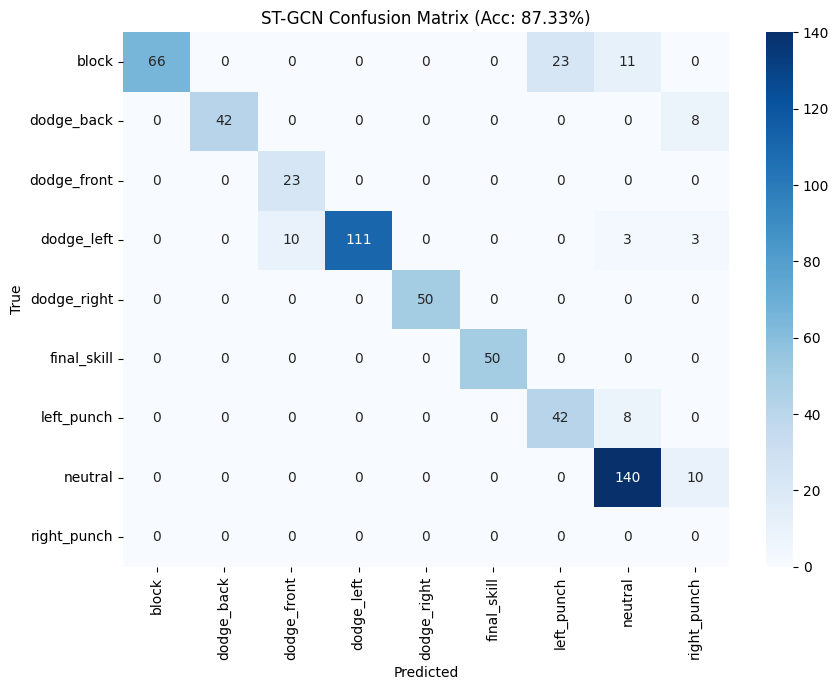

In [5]:
model.eval()
all_true = []
all_pred = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_pred.extend(pred)
        all_true.extend(yb.numpy())

all_true = np.array(all_true)
all_pred = np.array(all_pred)

acc = accuracy_score(all_true, all_pred)
macro_f1 = f1_score(all_true, all_pred, average='macro')

y_true_txt = encoder.inverse_transform(all_true)
y_pred_txt = encoder.inverse_transform(all_pred)

print(f'Test Accuracy: {acc:.4f}')
print(f'Macro F1: {macro_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_true_txt, y_pred_txt))

cm = confusion_matrix(y_true_txt, y_pred_txt, labels=encoder.classes_)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f'ST-GCN Confusion Matrix (Acc: {acc*100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [6]:
sample = torch.tensor(X_test[:1], dtype=torch.float32).to(device)
with torch.no_grad():
    for _ in range(50):
        _ = model(sample)

runs = 300
t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(runs):
        _ = model(sample)
t1 = time.perf_counter()

latency_ms = (t1 - t0) / runs * 1000
print(f'Inference latency (1 sequence): {latency_ms:.4f} ms')

Inference latency (1 sequence): 1.0562 ms


In [7]:
from datetime import datetime

# Create timestamped folder for this run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_folder = f'stgcn_{timestamp}'

models_out = os.path.join(config.MODELS_DIR, 'model_comparison', 'stgcn', run_folder)
reports_out = os.path.join(config.PROJECT_ROOT, 'reports', 'model_comparison', 'stgcn', run_folder)
os.makedirs(models_out, exist_ok=True)
os.makedirs(reports_out, exist_ok=True)

print(f'Saving to run folder: {run_folder}')

# Save model artifacts
torch.save({
    'state_dict': model.state_dict(),
    'num_nodes': int(NUM_NODES),
    'window_size': int(WINDOW_SIZE),
    'landmark_ids': list(LANDMARK_IDS),
    'num_classes': int(len(encoder.classes_)),
    'classes': list(encoder.classes_)
}, os.path.join(models_out, 'stgcn_model.pt'))

with open(os.path.join(models_out, 'stgcn_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(models_out, 'stgcn_label_encoder.pkl'), 'wb') as f:
    pickle.dump(encoder, f)

# Save confusion matrix
cm_path = os.path.join(reports_out, 'confusion_matrix.png')
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f'ST-GCN Confusion Matrix (Acc: {acc*100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(cm_path, dpi=160)
plt.close()

# Save metrics
metrics = {
    'model': 'ST-GCN (Lightweight)',
    'timestamp': timestamp,
    'run_folder': run_folder,
    'accuracy': float(acc),
    'macro_f1': float(macro_f1),
    'inference_latency_ms': float(latency_ms),
    'train_samples': int(len(X_train)),
    'val_samples': int(len(X_val)),
    'test_samples': int(len(X_test)),
    'window_size': int(WINDOW_SIZE),
    'num_nodes': int(NUM_NODES),
    'coords_per_node': 3,
    'classes': list(encoder.classes_)
}

metrics_path = os.path.join(reports_out, 'metrics.json')
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

# Also save to root comparison folder for summary
root_metrics_path = os.path.join(config.PROJECT_ROOT, 'reports', 'model_comparison', 'stgcn_metrics.json')
with open(root_metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(f'✓ Saved model to: {models_out}')
print(f'✓ Saved reports to: {reports_out}')
print(f'✓ Metrics: {metrics_path}')

Saving to run folder: stgcn_20260305_230138


✓ Saved model to: D:\ML-AI Motion Controller\models\model_comparison\stgcn\stgcn_20260305_230138
✓ Saved reports to: D:\ML-AI Motion Controller\reports\model_comparison\stgcn\stgcn_20260305_230138
✓ Metrics: D:\ML-AI Motion Controller\reports\model_comparison\stgcn\stgcn_20260305_230138\metrics.json
